In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
base_dir = '/content/drive/MyDrive/HAM10000'
split_dir = os.path.join(base_dir, 'splits')
raw_dir = os.path.join(base_dir, 'raw')

part1_dir = os.path.join(raw_dir, 'HAM10000_images_part_1')
part2_dir = os.path.join(raw_dir, 'HAM10000_images_part_2')

In [6]:
# ====================== LOAD CSV (SPLITS) ======================
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

train_df = pd.read_csv(os.path.join(split_dir, 'train_split.csv'))
val_df   = pd.read_csv(os.path.join(split_dir, 'val_split.csv'))
test_df  = pd.read_csv(os.path.join(split_dir, 'test_split.csv'))

class_names = np.load(os.path.join(base_dir, 'class_names.npy'), allow_pickle=True).tolist()
NUM_CLASSES = len(class_names)

print(f"✅ Load splits thành công!")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes: {class_names}")
print(f"\nCác cột trong train_df: {train_df.columns.tolist()}")

# ====================== XÁC ĐỊNH CỘT QUAN TRỌNG ======================
image_col = 'image_id'
label_col = 'dx'
print(f"→ Sử dụng cột ảnh: '{image_col}' | cột nhãn: '{label_col}'")

# ====================== THÊM ĐUÔI .jpg + TẠO ĐƯỜNG DẪN ĐẦY ĐỦ ======================
for df in [train_df, val_df, test_df]:
    # Thêm đuôi .jpg nếu chưa có
    df[image_col] = df[image_col].astype(str).apply(lambda x: x if x.lower().endswith('.jpg') else x + '.jpg')

    # Ưu tiên dùng cột image_path nếu có và hợp lệ, ngược lại tự tìm trong 2 part
    if 'image_path' in df.columns:
        df['full_path'] = df['image_path'].where(df['image_path'].notna() & df['image_path'].astype(str).str.contains('HAM10000_images'), None)

    # Nếu chưa có full_path hợp lệ thì tìm trong part_1 và part_2
    def find_image_path(img_name):
        for part_dir in [part1_dir, part2_dir]:
            path = os.path.join(part_dir, img_name)
            if os.path.exists(path):
                return path
        return None

    mask = df.get('full_path', pd.Series([None]*len(df))).isnull()
    df.loc[mask, 'full_path'] = df.loc[mask, image_col].apply(find_image_path)

# Kiểm tra ảnh bị thiếu
missing_train = train_df['full_path'].isnull().sum()
if missing_train > 0:
    print(f"⚠️ Cảnh báo: {missing_train} ảnh trong train không tìm thấy!")
else:
    print('✅ All train images resolved')

✅ Load splits thành công!
Train: 7010 | Val: 1502 | Test: 1503
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Các cột trong train_df: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label', 'image_path']
→ Sử dụng cột ảnh: 'image_id' | cột nhãn: 'dx'
✅ All train images resolved


✅ Train: 7010 | Val: 1502 | Test: 1503
Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


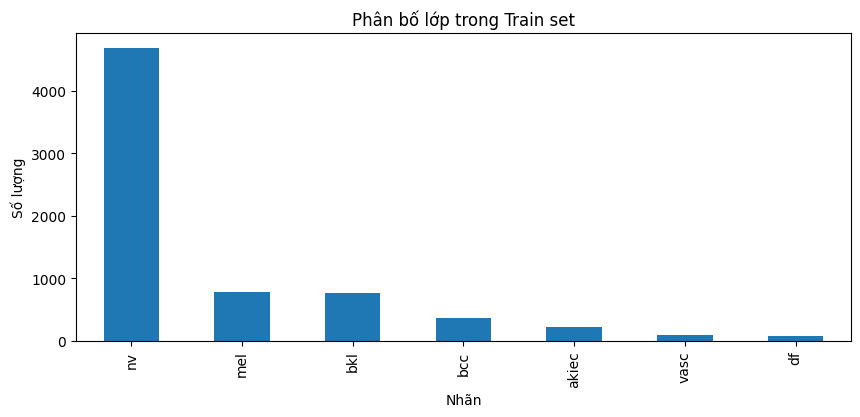

In [7]:
print(f"✅ Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes ({len(class_names)}): {class_names}")

# Kiểm tra class distribution
plt.figure(figsize=(10,4))
train_df['dx'].value_counts().plot(kind='bar')
plt.title('Phân bố lớp trong Train set')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.show()

In [14]:
# ====================== IMBALANCE HANDLING + DATA AUGMENTATION ======================
# Pipeline giữ giống v1 (flow_from_dataframe + full_path), paper input 224x224, one-hot labels.

# ---- Config ----
img_size = (224, 224)
batch_size = 32

# Mất cân bằng: ưu tiên class_weight; oversampling chỉ bật khi recall lớp hiếm quá thấp.
USE_CLASS_WEIGHT = True
USE_OVERSAMPLING = False
OVERSAMPLE_TARGET_QUANTILE = 0.60  # mục tiêu số mẫu/lớp sau oversample
OVERSAMPLE_MAX_MULT = 6            # giới hạn nhân bản tối đa mỗi lớp

# Class-weight tuning (nếu macro-F1 thấp):
WEIGHT_SMOOTHING = 'sqrt'   # 'sqrt' (mặc định, ổn định) | 'none' (mạnh hơn)
WEIGHT_CLIP_MIN = 0.50
WEIGHT_CLIP_MAX = 6.00

# ---- Distribution ----
class_counts = train_df[label_col].value_counts().reindex(class_names, fill_value=0)
print('📊 Train class distribution:')
print(class_counts)

# ---- Optional oversampling (duplicate rows) ----
train_df_used = train_df
if USE_OVERSAMPLING:
    target = int(np.quantile(class_counts.values, OVERSAMPLE_TARGET_QUANTILE))
    parts = []
    for cls in class_names:
        cls_df = train_df[train_df[label_col] == cls]
        n = len(cls_df)
        if n == 0:
            continue
        desired = min(max(n, target), n * OVERSAMPLE_MAX_MULT)
        extra_n = max(0, desired - n)
        if extra_n > 0:
            extra = cls_df.sample(extra_n, replace=True, random_state=SEED)
            parts.append(pd.concat([cls_df, extra], axis=0))
        else:
            parts.append(cls_df)
    train_df_used = pd.concat(parts, axis=0).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    print('✅ Oversampling enabled | new train size:', len(train_df_used))
    print(train_df_used[label_col].value_counts().reindex(class_names, fill_value=0))

# ---- Class weights (balanced -> optional smooth -> clip) ----
class_weight_dict = None
if USE_CLASS_WEIGHT:
    w = compute_class_weight(class_weight='balanced', classes=np.array(class_names), y=train_df[label_col].values)
    w = pd.Series(w, index=class_names).astype(float)
    if WEIGHT_SMOOTHING == 'sqrt':
        w = np.sqrt(w)
    elif WEIGHT_SMOOTHING == 'none':
        pass
    else:
        raise ValueError("WEIGHT_SMOOTHING must be 'sqrt' or 'none'")
    w = w / w.mean()
    w = w.clip(lower=WEIGHT_CLIP_MIN, upper=WEIGHT_CLIP_MAX)
    w = w / w.mean()
    weight_by_label = w.to_dict()
    class_weight_dict = {i: float(weight_by_label[class_names[i]]) for i in range(len(class_names))}
    print('⚖️ class_weight_dict:', class_weight_dict)

# ---- Augmentation (nhẹ) ----
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest',
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# ---- Generators (one-hot) ----
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_used,
    x_col='full_path',
    y_col=label_col,
    classes=class_names,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=SEED,
)
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='full_path',
    y_col=label_col,
    classes=class_names,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
)
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='full_path',
    y_col=label_col,
    classes=class_names,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
)

print('✅ Generators ready | img_size:', img_size, '| batch_size:', batch_size)

📊 Train class distribution:
dx
akiec     229
bcc       360
bkl       769
df         81
mel       779
nv       4693
vasc       99
Name: count, dtype: int64
⚖️ class_weight_dict: {0: 1.0706004682683996, 1: 0.853874255718445, 2: 0.5842275061964679, 3: 1.8001249889675606, 4: 0.580465538509481, 5: 0.4824329248447231, 6: 1.6282743174949232}
Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
✅ Generators ready | img_size: (224, 224) | batch_size: 32


In [18]:
# ====================== QUICK SANITY CHECK (DATA) ======================
x_batch, y_batch = next(iter(train_generator))
print('Batch X:', x_batch.shape, x_batch.dtype, '| min/max:', float(x_batch.min()), float(x_batch.max()))
print('Batch Y:', y_batch.shape, y_batch.dtype, '| row-sum example:', float(y_batch[0].sum()))
print('Class indices:', train_generator.class_indices)

Batch X: (32, 224, 224, 3) float32 | min/max: 0.0 1.0
Batch Y: (32, 7) float32 | row-sum example: 1.0
Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [19]:
# ====================== TRAINING SETUP ======================
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras

EPOCHS = 30
LEARNING_RATE = 1e-3

CKPT_DIR = "/content/drive/MyDrive/DA_checkpoints/CNN_V2"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, 'lightweight_cnn_best.keras')

print('✅ epochs:', EPOCHS, '| lr:', LEARNING_RATE)
print('✅ checkpoint:', CKPT_PATH)

✅ epochs: 30 | lr: 0.001
✅ checkpoint: /content/drive/MyDrive/DA_checkpoints/CNN_V2/lightweight_cnn_best.keras


In [20]:
# ====================== LIGHTWEIGHT CNN (PAPER ARCHITECTURE) ======================
# Note: để khớp bảng trong paper (output shape giữ nguyên sau Conv2D), dùng padding='same'.
from tensorflow.keras import layers

def build_lightweight_cnn(input_shape=(224, 224, 3), num_classes=7):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='LightweightCNN_HAM10000')

model = build_lightweight_cnn(input_shape=(img_size[0], img_size[1], 3), num_classes=NUM_CLASSES)
model.summary()

# ---- Model size info ----
total_params = model.count_params()
# float32 ~ 4 bytes/param (weights only; optimizer states not included)
size_mb = total_params * 4 / (1024**2)
print(f"\n📦 Total params: {total_params:,}")
print(f"📦 Approx weights size (fp32): {size_mb:.2f} MB")

Model: "LightweightCNN_HAM10000"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,415 (98.36 MB)

 Trainable params: 25,785,415 (98.36 MB)

 Non-trainable params: 0 (0.00 B)


📦 Total params: 25,785,415
📦 Approx weights size (fp32): 98.36 MB


In [23]:
import numpy as np
from tensorflow import keras

# F1-score (macro) on validation each epoch (callback)
try:
    from sklearn.metrics import f1_score, precision_score, recall_score
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn'])
    from sklearn.metrics import f1_score, precision_score, recall_score

class MacroMetricsCallback(keras.callbacks.Callback):
    def __init__(self, val_gen, every_n_epochs=1):
        super().__init__()
        self.val_gen = val_gen
        self.every_n_epochs = int(max(1, every_n_epochs))

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs != 0:
            return
        logs = logs or {}
        self.val_gen.reset()
        probs = self.model.predict(self.val_gen, verbose=0)
        y_pred = np.argmax(probs, axis=1)
        y_true = np.array(self.val_gen.classes).astype(int) # Fix: Convert to numpy array
        f1 = f1_score(y_true, y_pred, average='macro')
        p = precision_score(y_true, y_pred, average='macro', zero_division=0)
        r = recall_score(y_true, y_pred, average='macro', zero_division=0)
        logs['val_f1_macro'] = float(f1)
        logs['val_precision_macro'] = float(p)
        logs['val_recall_macro'] = float(r)
        print(f"val_precision_macro: {p:.4f} | val_recall_macro: {r:.4f} | val_f1_macro: {f1:.4f}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')],
)

callbacks = [
    # put macro-metrics first so later callbacks can monitor val_f1_macro
    MacroMetricsCallback(val_generator, every_n_epochs=1),
    keras.callbacks.ModelCheckpoint(
        filepath=str(CKPT_PATH),
        monitor='val_f1_macro',
        mode='max',
        save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_f1_macro',
        mode='max',
        patience=6,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print('✅ Model compiled and callbacks ready (val_precision/recall/f1 macro enabled)')

✅ Model compiled and callbacks ready (val_precision/recall/f1 macro enabled)


In [24]:
# ====================== TRAIN ======================
# Nếu bật mất cân bằng: class_weight_dict != None sẽ được áp dụng.
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1,
 )

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.6710 - loss: 0.6965val_precision_macro: 0.3136 | val_recall_macro: 0.2417 | val_f1_macro: 0.1591
220/220 ━━━━━━━━━━━━━━━━━━━━ 199s 886ms/step - accuracy: 0.6658 - loss: 0.6827 - val_accuracy: 0.6445 - val_loss: 1.0336 - val_f1_macro: 0.1591 - val_precision_macro: 0.3136 - val_recall_macro: 0.2417 - learning_rate: 0.0010
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.6747 - loss: 0.6228val_precision_macro: 0.3098 | val_recall_macro: 0.2941 | val_f1_macro: 0.2423
220/220 ━━━━━━━━━━━━━━━━━━━━ 200s 909ms/step - accuracy: 0.6742 - loss: 0.6186 - val_accuracy: 0.6818 - val_loss: 0.9284 - val_f1_macro: 0.2423 - val_precision_macro: 0.3098 - val_recall_macro: 0.2941 - learning_rate: 0.0010
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.6773 - loss: 0.6101val_precision_macro: 0.2750 | val_recall_macro: 0.1930 | val_f1_macro: 0.1820
220/220 ━━━━━━━━━━━━━━━━━━━━ 194s 883ms/step - accuracy

In [ ]:
print(f"Tiếp tục train thêm 10 epoch...")

history_continued = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10, # Train thêm 10 epoch
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1,
)

# Cập nhật đối tượng history để có thể vẽ biểu đồ liền mạch nếu cần
for key, value in history_continued.history.items():
    if key in history.history:
        history.history[key].extend(value)
    else:
        history.history[key] = value

print("Đã hoàn thành train thêm 10 epoch.")

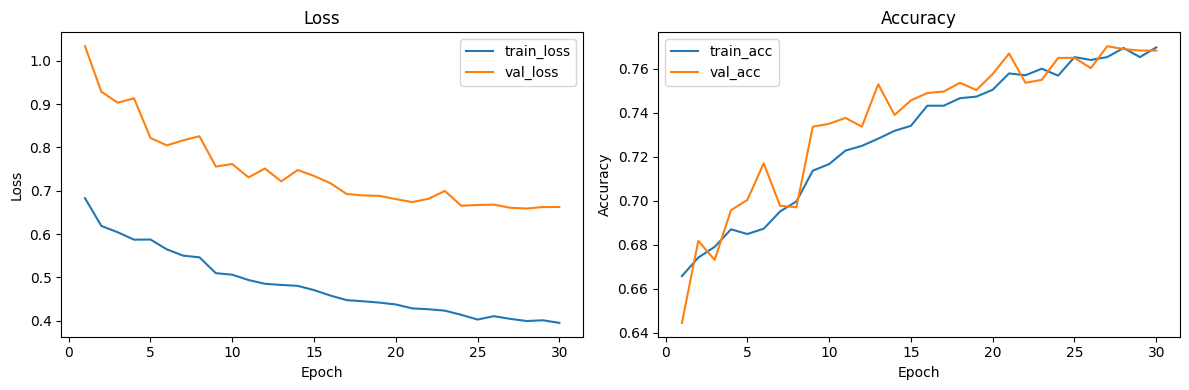

In [26]:
# ====================== PLOT TRAINING CURVES ======================
import matplotlib.pyplot as plt

hist = history.history
epochs_range = range(1, len(hist.get("loss", [])) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist.get("loss", []), label="train_loss")
plt.plot(epochs_range, hist.get("val_loss", []), label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist.get("accuracy", []), label="train_acc")
plt.plot(epochs_range, hist.get("val_accuracy", []), label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 439ms/step - accuracy: 0.7465 - loss: 0.6890

TEST metrics:
  loss: 0.6890
  compile_metrics: 0.7465
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 347ms/step

TEST F1 macro: 0.4945
TEST F1 weighted: 0.7316

Classification Report:
              precision    recall  f1-score   support

       akiec       0.40      0.45      0.42        49
         bcc       0.60      0.62      0.61        77
         bkl       0.45      0.40      0.42       165
          df       0.22      0.12      0.15        17
         mel       0.48      0.29      0.36       167
          nv       0.85      0.92      0.88      1006
        vasc       0.62      0.59      0.60        22

    accuracy                           0.75      1503
   macro avg       0.52      0.48      0.49      1503
weighted avg       0.72      0.75      0.73      1503



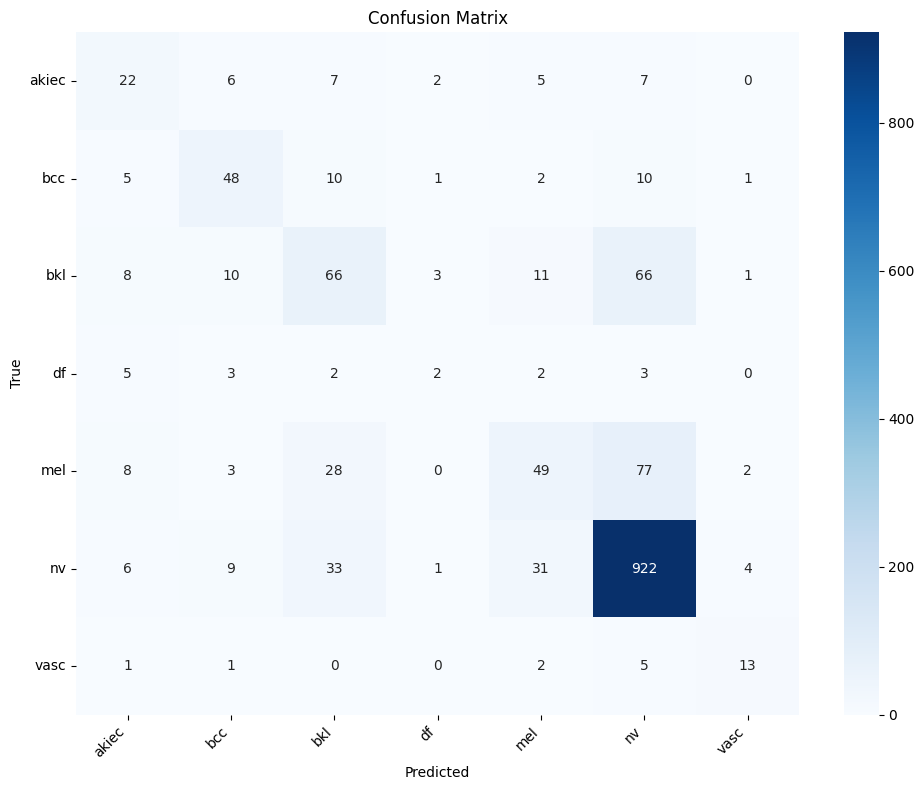

,precision,recall,f1-score,support
akiec,0.400000,0.448980,0.423077,49.0
bcc,0.600000,0.623377,0.611465,77.0
bkl,0.452055,0.400000,0.424437,165.0
df,0.222222,0.117647,0.153846,17.0
mel,0.480392,0.293413,0.364312,167.0


In [28]:
# ====================== EVALUATE ON TEST (METRICS + REPORT + CONFUSION MATRIX) ======================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Evaluate scalar metrics from model.compile()
results = model.evaluate(test_generator, verbose=1)
print('\nTEST metrics:')
for name, value in zip(model.metrics_names, results):
    print(f"  {name}: {value:.4f}")

# Predict probabilities
probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(probs, axis=1)

# True labels from generator
y_true = np.array(test_generator.classes).astype(int)

# F1-score on test
test_f1_macro = f1_score(y_true, y_pred, average='macro')
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')
print(f"\nTEST F1 macro: {test_f1_macro:.4f}")
print(f"TEST F1 weighted: {test_f1_weighted:.4f}")

# Class name order follows generator indices
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
ordered_class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=ordered_class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ordered_class_names, yticklabels=ordered_class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class metric table (for optional plotting)
report = classification_report(y_true, y_pred, target_names=ordered_class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head()

In [29]:
# ====================== LOAD BEST CHECKPOINT + RE-EVALUATE ======================
from tensorflow import keras

if os.path.exists(CKPT_PATH):
    best_model = keras.models.load_model(CKPT_PATH)
    best_loss, best_acc = best_model.evaluate(test_generator, verbose=1)
    print(f"\nBEST CKPT TEST | loss={best_loss:.4f} | acc={best_acc:.4f}")
else:
    print("⚠️ Không thấy checkpoint ở:", CKPT_PATH)

47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 346ms/step - accuracy: 0.7458 - loss: 0.6890

BEST CKPT TEST | loss=0.6890 | acc=0.7458


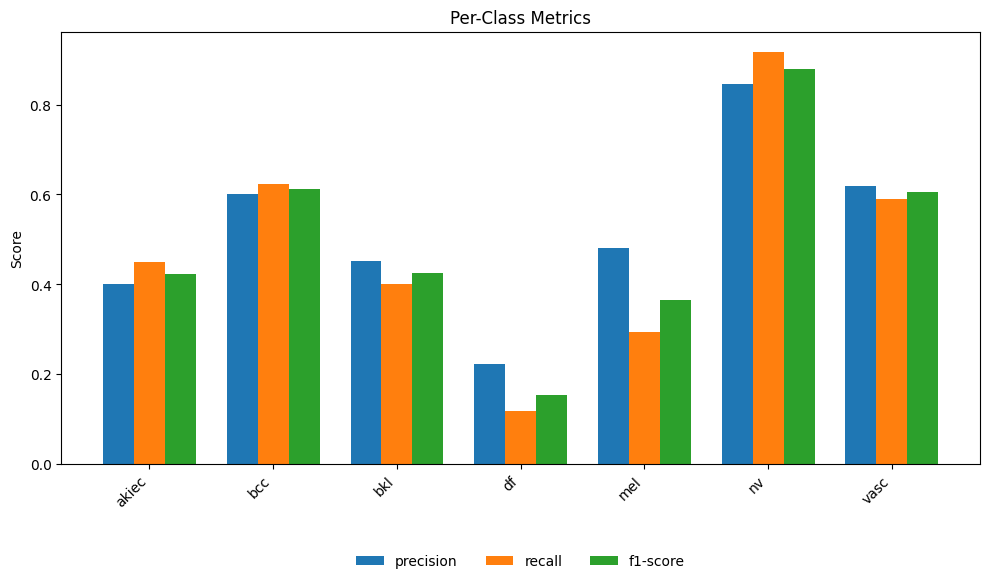

In [30]:
# ====================== (OPTIONAL) PER-CLASS METRIC BARS ======================
import numpy as np
import matplotlib.pyplot as plt

if 'df_report' not in locals():
    print("⚠️ Chưa có df_report. Hãy chạy cell Evaluate trước.")
else:
    class_rows = df_report.index.difference(["accuracy", "macro avg", "weighted avg"])
    df_cls = df_report.loc[class_rows].copy()

    metrics = ["precision", "recall", "f1-score"]
    class_names_plot = df_cls.index.tolist()

    plt.figure(figsize=(10, 6))
    x = np.arange(len(class_names_plot))
    width = 0.25

    for i, m in enumerate(metrics):
        plt.bar(x + i * width, df_cls[m].values, width=width, label=m)

    plt.xticks(x + width, class_names_plot, rotation=45, ha='right')
    plt.ylabel("Score")
    plt.title("Per-Class Metrics")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()